# Assignment 1: Word Embeddings, Sentiments and Topics
**Course:** Large Language Models for Marketing (FEM11154)  
**Dataset:** Disneyland Reviews

---

## Step 1: Data Loading & Preprocessing

Before any analysis, we need to:
1. Load the CSV
2. Remove reviews that are empty or too short to be useful
3. Clean the text (strip HTML, lowercase, remove punctuation/stopwords)
4. Filter out non-English reviews
5. Inspect the final dataset

In [2]:
# Installed required libraries
!pip install pandas nltk langdetect gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.0 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9119e0105715ff19748c94a8f8e4ce724a9c2d350411367b1b5267e30ed13bbc
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [4]:
import pandas as pd
import re
import nltk

# Downloaded NLTK resources we need for tokenisation and stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Loaded data
df = pd.read_csv('/content/disneyland_review.csv', encoding='latin1')

print(f'Rows loaded: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Rows loaded: 42656
Columns: ['Review_ID', 'rating', 'Year_Month', 'Reviewer_Location', 'review', 'Branch']


,Review_ID,rating,Year_Month,Reviewer_Location,review,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong


In [28]:
# Looked at the rating distribution
print(df.columns.tolist())
print('Rating distribution:')
print(df['rating'].value_counts().sort_index())
print(f"\nMissing ratings: {df['rating'].isna().sum()}")

['Review_ID', 'rating', 'Year_Month', 'Reviewer_Location', 'review', 'Branch', 'word_count', 'is_english', 'review_clean', 'review_tokens', 'star_group']
Rating distribution:
rating
1     1498
2     2123
3     5091
4    10722
5    22931
Name: count, dtype: int64

Missing ratings: 0


In [29]:
# Step 1a: Droped rows with empty or very short reviews
# We need actual text to analyse — reviews under 15 words are too short
# to be meaningful for embeddings or topic modelling.

df['review'] = df['review'].fillna('')           # treat NaN as empty string
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

before = len(df)
df = df[df['word_count'] >= 15].copy()
print(f'Removed {before - len(df)} rows (empty or < 15 words). Remaining: {len(df)}')

# Removed duplicate reviews
before = len(df)
df = df.drop_duplicates(subset=['review']).copy()
print(f'Removed {before - len(df)} duplicate reviews. Remaining: {len(df)}')

Removed 0 rows (empty or < 15 words). Remaining: 42365
Removed 0 duplicate reviews. Remaining: 42365


In [30]:
# Step 1b: Filtered non-English reviews
# langdetect guesses the language of each review
# We kept only English ones to ensure consistent NLP processing

from langdetect import detect, LangDetectException

def is_english(text):
    try:
        return detect(str(text)) == 'en'
    except LangDetectException:
        return False

print('Detecting languages (this may take ~30 seconds)...')
df['is_english'] = df['review'].apply(is_english)

before = len(df)
df = df[df['is_english']].copy()
print(f'Removed {before - len(df)} non-English reviews. Remaining: {len(df)}')

Detecting languages (this may take ~30 seconds)...
Removed 0 non-English reviews. Remaining: 42365


In [31]:
# Step 1c: Cleaned the raw text
# We do two versions:
#   - review_clean : readable text, used for BERTopic and sentiment analysis
#   - review_tokens: list of lowercase words, used for Word2Vec training

STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    """Remove HTML tags, URLs, and extra whitespace. Keep punctuation for readability."""
    text = str(text) if text is not None else ''  # handle NaN/float values
    text = re.sub(r'<.*?>', ' ', text)          # strip HTML tags like <br>
    text = re.sub(r'http\S+', '', text)          # strip URLs
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    return text

def tokenize(text):
    """Lowercase, remove punctuation and stopwords, return list of words."""
    text = clean_text(text)
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
    return tokens

df['review_clean']  = df['review'].apply(clean_text)
df['review_tokens'] = df['review'].apply(tokenize)

# Preview
print('Original review:')
print(df['review'].iloc[0][:300])
print('\nCleaned:')
print(df['review_clean'].iloc[0][:300])
print('\nTokenised (first 20 tokens):')
print(df['review_tokens'].iloc[0][:20])

Original review:
If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides  its a Small World  is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but t

Cleaned:
If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street! It has a very familiar feel. One of the rides its a Small World is absolutely fabulous and worth doing. The day we visited was fairly hot and relatively busy but the

Tokenised (first 20 tokens):
['ever', 'disneyland', 'anywhere', 'find', 'disneyland', 'hong', 'kong', 'similar', 'layout', 'walk', 'main', 'street', 'familiar', 'feel', 'one', 'rides', 'small', 'world', 'absolutely', 'fabulous']


Final dataset size: 42365 reviews
Average word count: 130.5 words

Rating distribution after cleaning:
rating
1     1498
2     2123
3     5091
4    10722
5    22931
Name: count, dtype: int64


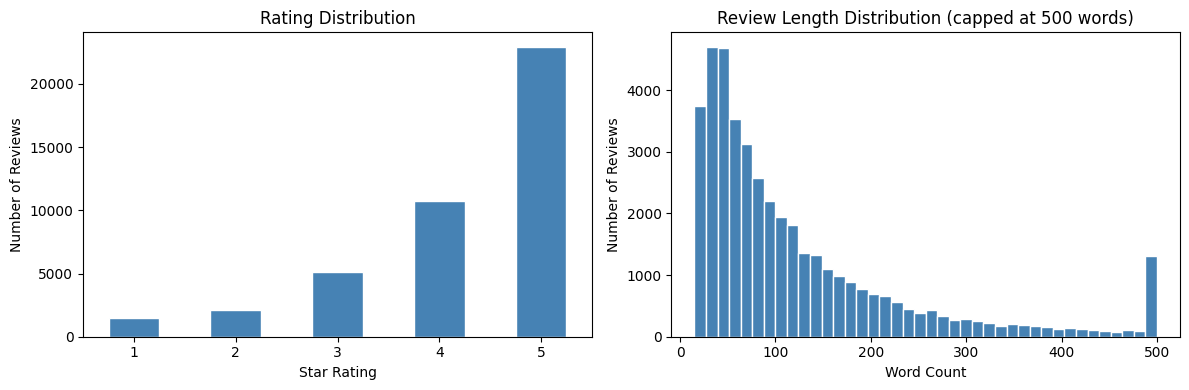

Plot saved to plots/01_data_overview.png


In [32]:
# Step 1d: Final dataset summary
import matplotlib.pyplot as plt

print(f'Final dataset size: {len(df)} reviews')
print(f"Average word count: {df['word_count'].mean():.1f} words")
print(f"\nRating distribution after cleaning:")
print(df['rating'].value_counts().sort_index())

# Plot rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=0)

df['word_count'].clip(upper=500).plot(kind='hist', bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Review Length Distribution (capped at 500 words)')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Number of Reviews')

plt.tight_layout()
# plt.savefig('plots/01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/01_data_overview.png')

## Step 2: Word Embeddings

We train a Word2Vec model on the cleaned, tokenized reviews, then explore the embedding space to understand how the model represents product-related concepts.

In [33]:
# Step 2a: Trained Word2Vec
# Word2Vec learns a 50-dimensional vector for each word by predicting
# neighbouring words in a sentence (Skip-Gram with window=5).
# min_count=5 drops words that appear fewer than 5 times (too rare to learn from).

from gensim.models import Word2Vec

sentences = df['review_tokens'].tolist()

model = Word2Vec(
    sentences=sentences,
    vector_size=50,    # embedding dimension d=50
    window=5,          # context window on each side
    min_count=5,       # ignores words seen fewer than 5 times
    workers=4,         # parallel training threads
    seed=42
)

vocab_size = len(model.wv)
print(f'Vocabulary size: {vocab_size} words')
print(f'Embedding shape: {model.wv.vectors.shape}')
print(f'\nSample vector for "disney" (first 10 dims):')
print(model.wv['disney'][:10])

Vocabulary size: 12160 words
Embedding shape: (12160, 50)

Sample vector for "disney" (first 10 dims):
[-0.5281222  -0.229112   -0.825802    0.11387546  1.1472954  -0.8616612
 -0.17202207 -1.1955692   0.40531665 -0.72519827]


In [11]:
# Step 2b: Quality axis ("excellent" → "horrible")
# A "direction" in embedding space is just the vector difference between
# two opposite words. Words that project highly onto this axis share
# meaning with the positive end; low projections share meaning with the negative end.

import numpy as np

pos_word, neg_word = 'excellent', 'horrible'
quality_axis = model.wv[pos_word] - model.wv[neg_word]  # direction vector

# Projected every word onto this axis
words = list(model.wv.index_to_key)
projections = {w: np.dot(model.wv[w], quality_axis) for w in words}

ranked = sorted(projections.items(), key=lambda x: x[1], reverse=True)

print(f'Quality axis: "{pos_word}" → "{neg_word}"\n')
print('Top 15 words (most positive / high quality):')
for w, score in ranked[:15]:
    print(f'  {w:20s} {score:+.3f}')

print('\nBottom 15 words (most negative / low quality):')
for w, score in ranked[-15:]:
    print(f'  {w:20s} {score:+.3f}')

Quality axis: "excellent" → "horrible"

Top 15 words (most positive / high quality):
  excellent            +72.343
  enjoyed              +69.404
  great                +64.327
  fantastic            +62.805
  amazing              +61.302
  loved                +60.111
  brilliant            +57.806
  wonderful            +57.223
  awesome              +56.734
  friendly             +55.634
  helpful              +52.903
  shows                +52.024
  good                 +50.968
  king                 +48.291
  lovely               +46.707

Bottom 15 words (most negative / low quality):
  stroller             -34.418
  thousands            -34.499
  cream                -35.153
  shoving              -35.474
  shoulder             -36.255
  bags                 -37.470
  heat                 -37.836
  security             -40.078
  pushing              -41.339
  push                 -41.417
  people               -42.610
  bag                  -42.758
  smoke                -46.018

In [34]:
# Step 2c: Inspected one embedding dimension
# Each of the 50 dimensions is a learned feature. We can look at which words
# score highest/lowest on a single dimension to get a sense of what it captures.

DIM = 0  # choose this as the Dimension (0–49)

dim_scores = {w: model.wv[w][DIM] for w in words}
dim_ranked = sorted(dim_scores.items(), key=lambda x: x[1], reverse=True)

print(f'Dimension #{DIM}\n')
print('Highest-scoring words:')
for w, score in dim_ranked[:10]:
    print(f'  {w:20s} {score:+.4f}')

print('\nLowest-scoring words:')
for w, score in dim_ranked[-10:]:
    print(f'  {w:20s} {score:+.4f}')

Dimension #0

Highest-scoring words:
  paris                -0.5049
  disney               -0.5281
  disneyland           -0.6558
  park                 -2.9577
  time                 -3.0691
  world                -4.0660

Lowest-scoring words:
  paris                -0.5049
  disney               -0.5281
  disneyland           -0.6558
  park                 -2.9577
  time                 -3.0691
  world                -4.0660


In [35]:
# Step 2d: Analysis i — Nearest neighbours of brand-related words ───────────
# Words that are close in embedding space tend to appear in similar contexts.
# For brand words, this reveals what reviewers associate with each concept.

brand_words = ['disney', 'park', 'queue', 'ride', 'movie']

for word in brand_words:
    if word in model.wv:
        neighbors = model.wv.most_similar(word, topn=8)
        print(f'\nNearest neighbours of "{word}":')
        for neighbor, similarity in neighbors:
            print(f'  {neighbor:20s} cosine similarity: {similarity:.3f}')
    else:
        print(f'\n"{word}" not in vocabulary (too rare or filtered out)')


Nearest neighbours of "disney":
  disneyland           cosine similarity: 0.725
  dl                   cosine similarity: 0.557
  unlike               cosine similarity: 0.530
  disneylands          cosine similarity: 0.512
  fl                   cosine similarity: 0.510
  original             cosine similarity: 0.499
  disneys              cosine similarity: 0.493
  united               cosine similarity: 0.475

Nearest neighbours of "park":
  parks                cosine similarity: 0.821
  however              cosine similarity: 0.539
  resort               cosine similarity: 0.510
  parc                 cosine similarity: 0.492
  disneyland           cosine similarity: 0.487
  attractions          cosine similarity: 0.472
  site                 cosine similarity: 0.464
  enough               cosine similarity: 0.463

Nearest neighbours of "queue":
  que                  cosine similarity: 0.928
  q                    cosine similarity: 0.873
  queues               cosine similarity

In [36]:
# Step 2e: Analysis ii — Word analogies
# Word2Vec captures analogical relationships via vector arithmetic.
# For example, "ride - queue + fun" asks: what is to fun what "ride" is to "queue"?
# Similarly, "staff - rude + helpful" surfaces words associated with positive staff experiences.
# We added the positive words and subtracted the negative word, then found the nearest result.
# This allows us to see how the model encodes sentiment-laden directions in the
# embedding space for key Disneyland experience dimensions (rides, staff, food, park atmosphere).

analogies = [
     # (positive words, negative words, interpretation)
    (['ride', 'fun'], ['queue'],   '"ride – queue + fun" → fun part of rides without waiting'),
    (['staff', 'helpful'], ['rude'], '"staff – rude + helpful" → positive staff experience'),
    (['food', 'expensive'], ['cheap'], '"food – cheap + expensive" → expensive food experience'),
    (['park', 'clean'], ['dirty'], '"park – dirty + clean" → clean park atmosphere'),
    (['disney', 'magic'], ['crowd'], '"disney – crowd + magic" → magical Disney experience without crowds'),

]


for positives, negatives, label in analogies:
    # Check all words exist in vocab before querying
    all_words = positives + negatives
    missing = [w for w in all_words if w not in model.wv]
    if missing:
        print(f'\n{label}')
        print(f'  Skipped — not in vocabulary: {missing}')
        continue
    results = model.wv.most_similar(positive=positives, negative=negatives, topn=5)
    print(f'\n{label}')
    for word, score in results:
        print(f'  {word:20s} {score:.3f}')


"ride – queue + fun" → fun part of rides without waiting
  exciting             0.618
  enjoyed              0.547
  blast                0.520
  enjoyable            0.520
  enjoy                0.514

"staff – rude + helpful" → positive staff experience
  staffs               0.566
  professional         0.563
  polite               0.555
  clean                0.546
  knowledgeable        0.515

"food – cheap + expensive" → expensive food experience
  restaurants          0.624
  foods                0.596
  mediocre             0.560
  mostly               0.549
  cafes                0.545

"park – dirty + clean" → clean park atmosphere
  parks                0.584
  disneyland           0.547
  day                  0.519
  still                0.491
  place                0.489

"disney – crowd + magic" → magical Disney experience without crowds
  dream                0.521
  disneyland           0.519
  animal               0.503
  magical              0.502
  walt             

## Step 3: Topic Modelling + Sentiment Analysis

We split each review into sentences, run BERTopic to discover recurring themes, then use VADER sentiment analysis to score each sentence. Finally, we compare topic prevalence and sentiment between low-rated (1–3★) and high-rated (4–5★) reviews.

In [37]:
# Installed Step 3 dependencies
!pip install bertopic sentence-transformers vaderSentiment

In [38]:
# Step 3a: Split reviews into sentences
# BERTopic works best on short, focused text — sentences rather than full reviews.
# We keep each sentence's metadata (review_id, rating, star_group) for later aggregation.

from nltk.tokenize import sent_tokenize

df['star_group'] = df['rating'].apply(lambda r: 'low (1-3★)' if r <= 3 else 'high (4-5★)')

sentences_data = []
for idx, row in df.iterrows():
    for sent in sent_tokenize(row['review_clean']):
        if len(sent.split()) >= 5:   # skip fragments
            sentences_data.append({
                'review_id': idx,
                'rating':    row['rating'],
                'star_group': row['star_group'],
                'sentence':  sent
            })

sdf = pd.DataFrame(sentences_data)
print(f'Total sentences: {len(sdf)}')
print(f'\nSample:')
print(sdf['sentence'].head(3).tolist())

Total sentences: 283922

Sample:
["If you've ever been to Disneyland anywhere you'll find Disneyland Hong Kong very similar in the layout when you walk into main street!", 'It has a very familiar feel.', 'One of the rides its a Small World is absolutely fabulous and worth doing.']


In [26]:
#We ran the below for once to generate the outputs; however it took a long time and as a result we found a workaround to run the code faster for each time we ran it below.
# Step 3b: Run BERTopic
# BERTopic embeds sentences with a transformer, clusters them with HDBSCAN,
# and labels each cluster with the most representative words.
#
# Strategy: fit on a 25k random sample (fast), then predict on all sentences.
# This gives the same topic definitions without the cost of embedding all sentences twice.
#
# CountVectorizer removes stopwords from topic labels (e.g. 'the', 'and', 'it').

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

sample = sdf.sample(n=25000, random_state=42)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=CountVectorizer(stop_words='english'),
    nr_topics=15,
    min_topic_size=200,
    verbose=True
)
topic_model.fit(sample['sentence'].tolist())

# Predict topics for all sentences
topics, _ = topic_model.transform(sdf['sentence'].tolist())
sdf['topic'] = topics

# Show discovered topics
topic_info = topic_model.get_topic_info()
print('\nDiscovered topics:')
for _, row in topic_info.iterrows():
    top_words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outlier sentences)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(top_words)}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

KeyboardInterrupt: 

In [20]:
import os
os.makedirs('models', exist_ok=True)
sdf.to_pickle('models/sdf_topics.pkl')
topic_model.save('models/bertopic_model', serialization='pickle')
print('Saved!')

NameError: name 'topic_model' is not defined

In [19]:
# Saved BERTopic results to Google Drive (run once after Step 3b)
# After this, shared the Drive folder within our group.
# Everyone uses the Load cell below instead of rerunning BERTopic.

from google.colab import drive
drive.mount('/content/drive')

import os
save_path = '/content/drive/MyDrive/assignment1_models'
os.makedirs(save_path, exist_ok=True)

sdf.to_pickle(f'{save_path}/disney_sdf_topics.pkl')
topic_model.save(f'{save_path}/disney_bertopic_model', serialization='pickle')
print(f'Saved to Google Drive: {save_path}')




Mounted at /content/drive


FileExistsError: [Errno 17] File exists: '/content/drive/MyDrive/assignment1_models'

In [39]:
import subprocess
result = subprocess.run(['find', '/content/drive', '-name', 'disney_sdf_topics.pkl'],
                      capture_output=True, text=True)
print(result.stdout)

#Ran this for Step 3B
# Load BERTopic results from Google Drive (everyone else runs this)
# This way we skip the training cell entirely and run this instead.

from google.colab import drive
drive.mount('/content/drive')

from bertopic import BERTopic
import warnings
warnings.filterwarnings('ignore')

save_path = '/content/drive/.shortcut-targets-by-id/1aJGiyzKMwnYatXyDxJaUxo0D1s4kN_qa/assignment1_models'
sdf = pd.read_pickle(f'{save_path}/disney_sdf_topics.pkl')
topic_model = BERTopic.load(f'{save_path}/disney_bertopic_model')
print('Loaded from Google Drive!')

topic_info = topic_model.get_topic_info()
print('\nTopics:')
for _, row in topic_info.iterrows():
    words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outliers)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(words)}")

/content/drive/.shortcut-targets-by-id/1aJGiyzKMwnYatXyDxJaUxo0D1s4kN_qa/assignment1_models/disney_sdf_topics.pkl

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded from Google Drive!

Topics:
  Topic  -1 |  1608 sentences | (outliers)
  Topic   0 | 15884 sentences | rides, park, time, day, ride, food
  Topic   1 |   504 sentences | hong, kong, hk, disneyland, disney, visit
  Topic   2 |  1475 sentences | fireworks, parade, castle, parades, night, day
  Topic   3 |   224 sentences | characters, meet, character, photos, photo, autograph
  Topic   4 |  5305 sentences | disney, disneyland, park, paris, time, world


In [27]:
from bertopic import BERTopic
import warnings
warnings.filterwarnings('ignore')

sdf = pd.read_pickle('models/sdf_topics.pkl')
topic_model = BERTopic.load('models/bertopic_model')

print('Loaded sdf and topic_model from disk.')
topic_info = topic_model.get_topic_info()
print('\nTopics:')
for _, row in topic_info.iterrows():
    top_words = [w for w, _ in topic_model.get_topic(row['Topic'])][:6] if row['Topic'] != -1 else ['(outlier sentences)']
    print(f"  Topic {row['Topic']:3d} | {row['Count']:5d} sentences | {', '.join(top_words)}")

RepositoryNotFoundError: 401 Client Error. (Request ID: Root=1-69ccf050-0353cfc57dd5858b387f28ae;ed23389c-abf3-4f29-9d23-0e5983f98138)

Repository Not Found for url: https://huggingface.co/models/bertopic_model/resolve/main/topics.json.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Invalid username or password.

In [40]:
# Step 3c: Manually labeled topics
# After inspecting the top words above, assigned a human-readable label to each topic.
# Topic -1 is BERTopic's "outlier" bucket sentences that didn't fit any cluster.


TOPIC_LABELS = {
    -1: 'Outlier',
     0: 'Rides & Park Experience',
     1: 'Hong Kong Disneyland',
     2: 'Fireworks & Parades',
     3: 'Characters & Meet & Greet',
     4: 'Paris Disneyland',
}
sdf['topic_label'] = sdf['topic'].map(TOPIC_LABELS).fillna('Other')

print('Topic label distribution:')
print(sdf['topic_label'].value_counts().to_string())

Topic label distribution:
topic_label
Rides & Park Experience      178615
Paris Disneyland              60706
Outlier                       20707
Fireworks & Parades           16135
Hong Kong Disneyland           5556
Characters & Meet & Greet      2198


In [41]:
# Step 3d: Sentiment analysis with VADER
# VADER is a rule-based sentiment analyser tuned for short social/review text.
# The compound score ranges from -1 (very negative) to +1 (very positive).

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

sdf['sentiment'] = sdf['sentence'].apply(
    lambda s: analyzer.polarity_scores(s)['compound']
)

print('Sentiment score distribution:')
print(sdf['sentiment'].describe().round(3))
print(f"\nPositive sentences (>0.05):  {(sdf['sentiment'] >  0.05).sum()}")
print(f"Neutral  sentences (-0.05–0.05): {((sdf['sentiment'] >= -0.05) & (sdf['sentiment'] <= 0.05)).sum()}")
print(f"Negative sentences (<-0.05): {(sdf['sentiment'] < -0.05).sum()}")

Sentiment score distribution:
count    283917.000
mean          0.240
std           0.409
min          -0.986
25%           0.000
50%           0.226
75%           0.598
max           1.000
Name: sentiment, dtype: float64

Positive sentences (>0.05):  153810
Neutral  sentences (-0.05–0.05): 86484
Negative sentences (<-0.05): 43623


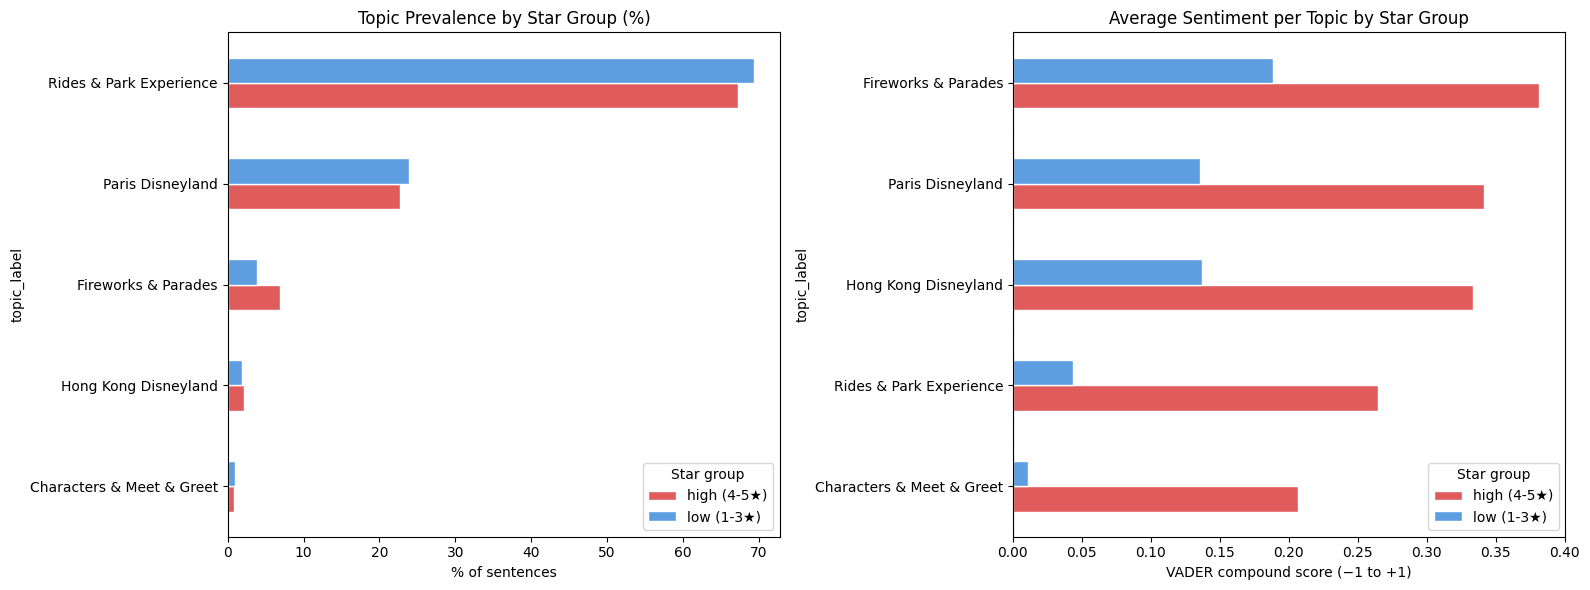

Plot saved to plots/03_topic_sentiment.png

Sentiment by topic and star group:
star_group                 high (4-5★)  low (1-3★)
topic_label                                       
Characters & Meet & Greet        0.207       0.011
Fireworks & Parades              0.382       0.188
Hong Kong Disneyland             0.333       0.137
Paris Disneyland                 0.341       0.136
Rides & Park Experience          0.265       0.044


In [48]:
# Step 3e: Comparative analysis — low vs high star reviews
# For each topic, compare:
#   1. Prevalence: what share of sentences in low/high reviews belong to this topic?
#   2. Sentiment: what is the average sentiment per topic in each group?

import matplotlib.pyplot as plt

# Exclude outliers from the comparison
sdf_clean = sdf[sdf['topic'] != -1].copy()

# ── Prevalence ────────────────────────────────────────────────────────────────
prevalence = (
    sdf_clean.groupby(['star_group', 'topic_label'])
    .size()
    .reset_index(name='count')
)
prevalence['pct'] = prevalence.groupby('star_group')['count'].transform(lambda x: x / x.sum() * 100)

prev_pivot = prevalence.pivot(index='topic_label', columns='star_group', values='pct').fillna(0)

# ── Sentiment ─────────────────────────────────────────────────────────────────
sent_pivot = (
    sdf_clean.groupby(['star_group', 'topic_label'])['sentiment']
    .mean()
    .unstack('star_group')
    .fillna(0)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

prev_pivot.sort_values('high (4-5★)', ascending=True).plot(
    kind='barh', ax=axes[0], color=['#e05c5c', '#5c9ee0'], edgecolor='white'
)
axes[0].set_title('Topic Prevalence by Star Group (%)')
axes[0].set_xlabel('% of sentences')
axes[0].legend(title='Star group')

sent_pivot.sort_values('high (4-5★)', ascending=True).plot(
    kind='barh', ax=axes[1], color=['#e05c5c', '#5c9ee0'], edgecolor='white'
)
axes[1].set_title('Average Sentiment per Topic by Star Group')
axes[1].set_xlabel('VADER compound score (−1 to +1)')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(title='Star group')

plt.tight_layout()
# plt.savefig('plots/03_topic_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to plots/03_topic_sentiment.png')

# Print summary table
print('\nSentiment by topic and star group:')
print(sent_pivot.round(3).to_string())

In [43]:
# Step 3f: Exemplar sentences per topic
for topic_num in [0, 1, 2, 3, 4]:
    label = TOPIC_LABELS[topic_num]
    print(f"\nTopic {topic_num} — {label}:")
    examples = sdf[sdf['topic'] == topic_num]['sentence'].sample(3, random_state=42).tolist()
    for ex in examples:
        print(f"  - {ex}")


Topic 0 — Rides & Park Experience:
  - and definitely worth the little extra).
  - The park was clean, efficiently run and a pleasure to visit.
  - The park was incredibly clean.

Topic 1 — Hong Kong Disneyland:
  - There is plenty of things to do in HK that is more interesting, unless you are a Disney addict.
  - The disney main attractions are Hong Kong Disneyland Band, Festival of lion king, Jungle river cruise,small wonder, mickey mouse 3D show, Disney on parade & much more.
  - A must visit when going to Hong Kong

Topic 2 — Fireworks & Parades:
  - Do not pass by the Water Dance Show at night fall.
  - Waited for the special disney parade but it was cancelled due to rain.
  - The park was spotless and the shows parades were all first class.

Topic 3 — Characters & Meet & Greet:
  - Sadly didn't have many with photo ops but was great.
  - Characters walking off with a line up of kids waiting and no notice this got really irritating.
  - Also, they have more character meals and me

Part 4: Drivers of Rating

In [49]:
# Built feature matrix per review
# Three types of predictors (all standardized later):
#   sentiment_overall : mean VADER score across all sentences in the review
#   share_<topic>     : fraction of sentences assigned to each topic
#   sent_<topic>      : mean sentiment of sentences about each topic (0 if none)

import pandas as pd
import numpy as np

def slugify(s):
    return str(s).replace(' & ', '').replace(' ', '').replace('/', '_')

# Used topic_label if it exists, otherwise referred to numeric topic id
label_col = 'topic_label' if 'topic_label' in sdf.columns else 'topic'

# i) Overall sentiment per review
sent_overall = sdf.groupby('review_id')['sentiment'].mean().rename('sentiment_overall')

# ii) Topic share per review (exclude outlier topic -1)
sdf_topics = sdf[sdf['topic'] != -1].copy()
topic_counts = sdf_topics.groupby(['review_id', label_col]).size().unstack(fill_value=0)
topic_shares = topic_counts.div(topic_counts.sum(axis=1), axis=0)
topic_shares.columns = [f'share_{slugify(c)}' for c in topic_shares.columns]

# iii) Topic-level sentiment per review
topic_sent = sdf_topics.groupby(['review_id', label_col])['sentiment'].mean().unstack(fill_value=0)
topic_sent.columns = [f'sent_{slugify(c)}' for c in topic_sent.columns]

# Merged with rating
features = df[['rating']].join(sent_overall).join(topic_shares).join(topic_sent)
features = features.dropna()

print(f'Feature matrix: {features.shape[0]} reviews x {features.shape[1]} columns')
print(f'  1 overall sentiment + {len([c for c in features.columns if c.startswith("share_")])} topic shares + {len([c for c in features.columns if c.startswith("sent_")])} topic sentiments')

Feature matrix: 42143 reviews x 12 columns
  1 overall sentiment + 5 topic shares + 5 topic sentiments


In [50]:
# OLS regression
# All predictors standardized to mean=0, unit variance so coefficients
# are directly comparable across variables.

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

y = features['rating']
X_raw = features.drop(columns=['rating'])

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    columns=X_raw.columns,
    index=X_raw.index
)
X_scaled = sm.add_constant(X_scaled)

ols = sm.OLS(y, X_scaled).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     1146.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:24:31   Log-Likelihood:                -57386.
No. Observations:               42143   AIC:                         1.148e+05
Df Residuals:                   42132   BIC:                         1.149e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

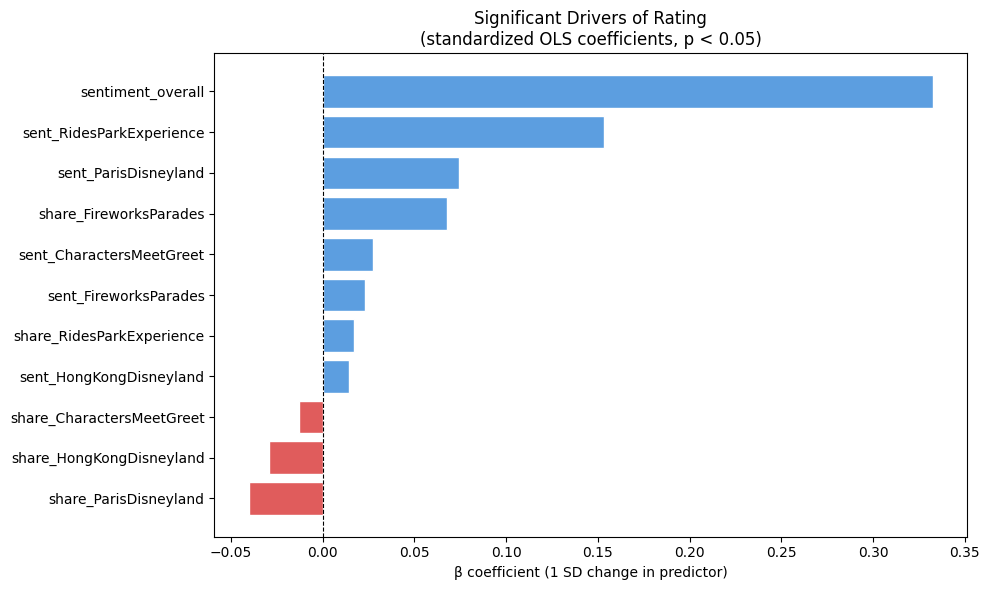

Saved: plots/05_regression_drivers.png


In [51]:
# Plotted significant drivers
import matplotlib.pyplot as plt
import os
os.makedirs('plots', exist_ok=True)

coef = ols.params.drop('const')
pval = ols.pvalues.drop('const')
sig  = coef[pval < 0.05].sort_values()

colors = ['#e05c5c' if v < 0 else '#5c9ee0' for v in sig.values]

fig, ax = plt.subplots(figsize=(10, max(6, len(sig) * 0.35)))
ax.barh(sig.index, sig.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Significant Drivers of Rating\n(standardized OLS coefficients, p < 0.05)')
ax.set_xlabel('β coefficient (1 SD change in predictor)')
plt.tight_layout()
plt.savefig('plots/05_regression_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/05_regression_drivers.png')

In [52]:
# Summary for the regression section
print('='*65)
print('i) OVERALL IMPACT OF REVIEWER SENTIMENT')
print('='*65)
b = ols.params['sentiment_overall']
p = ols.pvalues['sentiment_overall']
print(f'  sentiment_overall: β = {b:.3f}, p = {p:.4f}')
print(f'  A 1 SD increase in overall sentiment → {b:+.3f} change in rating')

print()
print('='*65)
print('ii) TOPICS WHERE SENTIMENT HAS THE STRONGEST IMPACT ON RATING')
print('='*65)
sent_coefs = ols.params[[c for c in ols.params.index if c.startswith('sent_')]]
sent_pvals = ols.pvalues[[c for c in ols.pvalues.index if c.startswith('sent_')]]
sent_sig = sent_coefs[sent_pvals < 0.05].reindex(
    sent_coefs[sent_pvals < 0.05].abs().sort_values(ascending=False).index
)
if len(sent_sig) == 0:
    print('  No significant topic-sentiment predictors found.')
for var, val in sent_sig.items():
    print(f'  {var:45s} β = {val:+.3f}  (p = {sent_pvals[var]:.4f})')

print()
print('='*65)
print('iii) TOPICS THAT DIRECTLY IMPACT THE DV (topic share)')
print('='*65)
share_coefs = ols.params[[c for c in ols.params.index if c.startswith('share_')]]
share_pvals = ols.pvalues[[c for c in ols.pvalues.index if c.startswith('share_')]]
share_sig = share_coefs[share_pvals < 0.05].sort_values(ascending=False)
if len(share_sig) == 0:
    print('  No significant topic-share predictors found.')
for var, val in share_sig.items():
    print(f'  {var:45s} β = {val:+.3f}  (p = {share_pvals[var]:.4f})')

print()
print(f'Model R² = {ols.rsquared:.3f}, Adj. R² = {ols.rsquared_adj:.3f}, N = {int(ols.nobs)}')

i) OVERALL IMPACT OF REVIEWER SENTIMENT
  sentiment_overall: β = 0.333, p = 0.0000
  A 1 SD increase in overall sentiment → +0.333 change in rating

ii) TOPICS WHERE SENTIMENT HAS THE STRONGEST IMPACT ON RATING
  sent_RidesParkExperience                      β = +0.154  (p = 0.0000)
  sent_ParisDisneyland                          β = +0.074  (p = 0.0000)
  sent_CharactersMeetGreet                      β = +0.028  (p = 0.0000)
  sent_FireworksParades                         β = +0.023  (p = 0.0000)
  sent_HongKongDisneyland                       β = +0.014  (p = 0.0124)

iii) TOPICS THAT DIRECTLY IMPACT THE DV (topic share)
  share_FireworksParades                        β = +0.068  (p = 0.0000)
  share_RidesParkExperience                     β = +0.017  (p = 0.0000)
  share_CharactersMeetGreet                     β = -0.013  (p = 0.0075)
  share_HongKongDisneyland                      β = -0.029  (p = 0.0000)
  share_ParisDisneyland                         β = -0.040  (p = 0.0000)

Mod